<a href="https://colab.research.google.com/github/Churrascooo/Practica-1/blob/main/CODIGOFINAL/Fase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explicación de la fase

Esta es la fase 1 del proyecto. Dentro de esta fase, hay 3 tareas principales, las cuales son: Importación de MIMIC-IV, análisis de MIIMC-IV y filtrado de la población geriátrica.

La primera tarea es importación de MIMIC-IV, consiste en importar ciertas tablas de la base de datos de MIMIC-IV. El formato de importación será desde Google Drive, ya que la base de datos MIMIC-IV es muy grande y colab no soporta tanto peso. Las tablas que se usarán en el proyecto son:

patients.csv.gz: Corresponde a la tabla con todos los pacientes, los cuales tienen sus datos desidentificados para proteger su identidad. De igual forma, las columnas útiles dentro de esta tabla es el ID del paciente, su género y el estimatimo de su edad.

admissions.csv.gz: Esta tabla tiene en sus columnas hadm_id, el cual es el ID único de hospitalización de cada paciente. Para fines prácticos, sólo se usará la última hospitalización de cada paciente, para así evitar duplicados. También, tiene el tiempo de admisión al hospital, una columna para saber si el paciente falleció, la hora de muerte, entre otros.

diagnoses_icd.csv.gz: Esta tabla tiene los diagnósticos de los pacientes, los cuales vienen con un código único para cada enfermedad. Como MIMIC-IV es una base de datos de varios años, hay 2 versiones de icd, la 9 y 10, siendo la última la más actual.

d_icd_diagnoses.csv.gz: Corresponde al diccionario con todos los códigos de los diagnósticos previamente explicados.

prescriptions.csv.gz: Esta tabla contiene los medicamentos que se le administran a los pacientes. Dichos medicamentos vienen con el nombre, la fecha de inicio y fin del tratamiento.

icustays.csv.gz: Corresponde a la estadía en la UCI (cuidados intensivos) de los pacientes. Contiene el tiempo de ingreso y salida en la UCI.

radiology.csv.gz: Dentro de esta tabla se encuentran las notas radiológicas que se realizan a los pacientes. Esta radiografía viene con texto, el cual sirve para entender bien los examenes que se pidió hacer a los pacientes.

---
La segunda tarea corresponde al análisis de MIMIC-IV. Esta consiste en ver el formato y así poder familiarizarse con las tablas previamente nombradas. Dentro de esta tarea, se podrá ver las dimensiones de las tablas, sus filas y columnas, etc.

---
La tercera tarea corresponde al filtrado de la población geriátrica. La idea de esto es que se junten las tablas poco a poco, filtrando cada una de ellas para así llegar a una cohorte de pacientes objetiva, la cual es los pacientes de tercera edad (mayores de 60 años).

# Importación de MIMIC-IV

In [ ]:
#Importar la base de datos de MIMIC-IV
#Se importará desde google drive, ya que la base de datos es muy grande y colab no soporta tanto peso

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Se listan solo las tablas de la base de datos de mimic MIMIC-IV que se usarán en el proyecto.

!find /content/drive/MyDrive -maxdepth 4 -type f \
    \( -name "patients.csv.gz" \
       -o -name "admissions.csv.gz" \
       -o -name "diagnoses_icd.csv.gz" \
       -o -name "d_icd_diagnoses.csv.gz" \
       -o -name "prescriptions.csv.gz" \
       -o -name "icustays.csv.gz" \
       -o -name "radiology.csv.gz" \)

/content/drive/MyDrive/patients.csv.gz
/content/drive/MyDrive/admissions.csv.gz
/content/drive/MyDrive/d_icd_diagnoses.csv.gz
/content/drive/MyDrive/prescriptions.csv.gz
/content/drive/MyDrive/icustays.csv.gz
/content/drive/MyDrive/radiology.csv.gz
/content/drive/MyDrive/diagnoses_icd.csv.gz


In [ ]:
#Se crea la estructura mínima de MIMIC-IV con las tablas usadas
#Directorios locales mínimos
!rm -rf /content/mimiciv_used
!mkdir -p /content/mimiciv_used/hosp
!mkdir -p /content/mimiciv_used/icu
!mkdir -p /content/mimiciv_used/notes

In [ ]:
#Bloque para copiar tablas desde drive
#Limpiar y crear estructura mínima local
!rm -rf /content/mimiciv_used
!mkdir -p /content/mimiciv_used/hosp
!mkdir -p /content/mimiciv_used/icu
!mkdir -p /content/mimiciv_used/notes

#HOSP
!cp /content/drive/MyDrive/patients.csv.gz        /content/mimiciv_used/hosp/
!cp /content/drive/MyDrive/admissions.csv.gz      /content/mimiciv_used/hosp/
!cp /content/drive/MyDrive/diagnoses_icd.csv.gz   /content/mimiciv_used/hosp/
!cp /content/drive/MyDrive/d_icd_diagnoses.csv.gz /content/mimiciv_used/hosp/
!cp /content/drive/MyDrive/prescriptions.csv.gz   /content/mimiciv_used/hosp/

#ICU
!cp /content/drive/MyDrive/icustays.csv.gz        /content/mimiciv_used/icu/

#NOTES
!cp /content/drive/MyDrive/radiology.csv.gz       /content/mimiciv_used/notes/

#Verificación OBLIGATORIA
!echo "=== HOSP ==="
!ls -lh /content/mimiciv_used/hosp

!echo "=== ICU ==="
!ls -lh /content/mimiciv_used/icu

!echo "=== NOTES ==="
!ls -lh /content/mimiciv_used/notes

=== HOSP ===
total 633M
-rw------- 1 root root  20M Feb 12 23:04 admissions.csv.gz
-rw------- 1 root root  33M Feb 12 23:04 diagnoses_icd.csv.gz
-rw------- 1 root root 856K Feb 12 23:04 d_icd_diagnoses.csv.gz
-rw------- 1 root root 2.8M Feb 12 23:04 patients.csv.gz
-rw------- 1 root root 579M Feb 12 23:04 prescriptions.csv.gz
=== ICU ===
total 3.2M
-rw------- 1 root root 3.2M Feb 12 23:04 icustays.csv.gz
=== NOTES ===
total 746M
-rw------- 1 root root 746M Feb 12 23:05 radiology.csv.gz


In [ ]:
#Se definen las rutas de trabajo

BASE_PATH = "/content/mimiciv_used" #Ruta base

HOSP_PATH  = f"{BASE_PATH}/hosp" #Ruta módulo hospital
ICU_PATH   = f"{BASE_PATH}/icu" #Ruta módulo icu
NOTES_PATH = f"{BASE_PATH}/notes" #Ruta módulo notas

#Ver resultados
print("Rutas configuradas:")
print("HOSP :", HOSP_PATH)
print("ICU  :", ICU_PATH)
print("NOTES:", NOTES_PATH)

Rutas configuradas:
HOSP : /content/mimiciv_used/hosp
ICU  : /content/mimiciv_used/icu
NOTES: /content/mimiciv_used/notes


# Análisis de MIMIC-IV

In [ ]:
#Importación de librerías

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os #Se importa os para interactuar con el sistema operativo y así manejar archivos

In [ ]:
#En este bloque se definen las rutas base del dataset MIMIC-IV, usando solo las tablas necesarias

HOSP_DIR  = os.path.join(BASE_PATH, "hosp") #Tablas hospitalarias
ICU_DIR   = os.path.join(BASE_PATH, "icu") #Tablas UCI
NOTES_DIR = os.path.join(BASE_PATH, "notes") #Notas clínicas (texto libre)

#Función para cargar tablas del módulo HOSP
#Se seleccionan solo columnas específicas para así optimizar memoria
def load_hosp(table, usecols=None):
    path = os.path.join(HOSP_DIR, f"{table}.csv.gz")
    return pd.read_csv(path, compression="gzip", usecols=usecols)

#Función para cargar tablas del módulo ICU
def load_icu(table, usecols=None):
    path = os.path.join(ICU_DIR, f"{table}.csv.gz")
    return pd.read_csv(path, compression="gzip", usecols=usecols)

In [ ]:
#Se carga la tabla "patients" que pertenece a hosp
#Se seleccionan solo las columnas relevantes para el análisis demográfico

patients = load_hosp(
    "patients",
    usecols=["subject_id", "gender", "anchor_age", "anchor_year"]
)

#Análisis para la tabla patients

print("patients shape:", patients.shape)
print("\nColumnas:", patients.columns.tolist())
print("\nDtypes:")
print(patients.dtypes)
print("\nHead:")
patients.head() #Ver los primeros datos

patients shape: (364627, 4)

Columnas: ['subject_id', 'gender', 'anchor_age', 'anchor_year']

Dtypes:
subject_id      int64
gender         object
anchor_age      int64
anchor_year     int64
dtype: object

Head:


,subject_id,gender,anchor_age,anchor_year
0,10000032,F,52,2180
1,10000048,F,23,2126
2,10000058,F,33,2168
3,10000068,F,19,2160
4,10000084,M,72,2160


In [ ]:
#Se carga la tabla "admissions" que pertenece a hosp
#Se seleccionan solo las columnas relevantes para el análisis demográfico

admissions = load_hosp(
    "admissions",
    usecols=[
        "subject_id",
        "hadm_id",
        "admittime",
        "dischtime",
        "deathtime",
        "hospital_expire_flag"
    ]
)

print("admissions shape:", admissions.shape)
print("\nColumnas:", admissions.columns.tolist())
print("\nDtypes:")
print(admissions.dtypes)
print("\nHead:")
admissions.head()

admissions shape: (546028, 6)

Columnas: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'hospital_expire_flag']

Dtypes:
subject_id               int64
hadm_id                  int64
admittime               object
dischtime               object
deathtime               object
hospital_expire_flag     int64
dtype: object

Head:


,subject_id,hadm_id,admittime,dischtime,deathtime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,0


In [ ]:
#Se carga la tabla "icustays" que pertenece a icu
#Se seleccionan solo las columnas relevantes para el análisis demográfico

icustays = load_icu(
    "icustays",
    usecols=[
        "subject_id",
        "hadm_id",
        "stay_id",
        "intime",
        "outtime"
    ]
)

print("icustays shape:", icustays.shape)
print("\nColumnas:", icustays.columns.tolist())
print("\nDtypes:")
print(icustays.dtypes)
print("\nHead:")
icustays.head()

icustays shape: (94458, 5)

Columnas: ['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime']

Dtypes:
subject_id     int64
hadm_id        int64
stay_id        int64
intime        object
outtime       object
dtype: object

Head:


,subject_id,hadm_id,stay_id,intime,outtime
0,10000032,29079034,39553978,2180-07-23 14:00:00,2180-07-23 23:50:47
1,10000690,25860671,37081114,2150-11-02 19:37:00,2150-11-06 17:03:17
2,10000980,26913865,39765666,2189-06-27 08:42:00,2189-06-27 20:38:27
3,10001217,24597018,37067082,2157-11-20 19:18:02,2157-11-21 22:08:00
4,10001217,27703517,34592300,2157-12-19 15:42:24,2157-12-20 14:27:41


In [ ]:
#Se carga la tabla "diagnoses" que pertenece a hosp
#Se seleccionan solo las columnas relevantes para el análisis demográfico

diagnoses = load_hosp(
    "diagnoses_icd",
    usecols=[
        "subject_id",
        "hadm_id",
        "seq_num",
        "icd_code",
        "icd_version"
    ]
)

print("diagnoses shape:", diagnoses.shape)
print("\nColumnas:", diagnoses.columns.tolist())
print("\nDtypes:")
print(diagnoses.dtypes)
print("\nHead:")
display(diagnoses.head())

diagnoses shape: (6364488, 5)

Columnas: ['subject_id', 'hadm_id', 'seq_num', 'icd_code', 'icd_version']

Dtypes:
subject_id      int64
hadm_id         int64
seq_num         int64
icd_code       object
icd_version     int64
dtype: object

Head:


,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9


In [ ]:
#Se carga la tabla "d_icd_diagnoses" que pertenece a hosp
#Se seleccionan solo las columnas relevantes para el análisis demográfico

icd_dict = load_hosp(
    "d_icd_diagnoses",
    usecols=[
        "icd_code",
        "icd_version",
        "long_title"
    ]
)

print("icd_dict shape:", icd_dict.shape)
print("\nColumnas:", icd_dict.columns.tolist())
print("\nDtypes:")
print(icd_dict.dtypes)
print("\nHead:")
display(icd_dict.head())

icd_dict shape: (112107, 3)

Columnas: ['icd_code', 'icd_version', 'long_title']

Dtypes:
icd_code       object
icd_version     int64
long_title     object
dtype: object

Head:


,icd_code,icd_version,long_title
0,0010,9,Cholera due to vibrio cholerae
1,0011,9,Cholera due to vibrio cholerae el tor
2,0019,9,"Cholera, unspecified"
3,0020,9,Typhoid fever
4,0021,9,Paratyphoid fever A


In [ ]:
#Se carga la tabla "prescriptions" que pertenece a hosp
#Se seleccionan solo las columnas relevantes para el análisis demográfico

prescriptions = load_hosp(
    "prescriptions",
    usecols=[
        "subject_id",
        "hadm_id",
        "starttime",
        "stoptime",
        "drug"
    ]
)

print("prescriptions shape:", prescriptions.shape)
print("\nColumnas:", prescriptions.columns.tolist())
print("\nDtypes:")
print(prescriptions.dtypes)
print("\nHead:")
display(prescriptions.head())

prescriptions shape: (20292611, 5)

Columnas: ['subject_id', 'hadm_id', 'starttime', 'stoptime', 'drug']

Dtypes:
subject_id     int64
hadm_id        int64
starttime     object
stoptime      object
drug          object
dtype: object

Head:


,subject_id,hadm_id,starttime,stoptime,drug
0,10000032,22595853,2180-05-08 08:00:00,2180-05-07 22:00:00,Furosemide
1,10000032,22595853,2180-05-07 02:00:00,2180-05-07 22:00:00,Ipratropium Bromide Neb
2,10000032,22595853,2180-05-07 01:00:00,2180-05-07 09:00:00,Furosemide
3,10000032,22595853,2180-05-07 01:00:00,2180-05-07 01:00:00,Potassium Chloride
4,10000032,22595853,2180-05-07 00:00:00,2180-05-07 22:00:00,Sodium Chloride 0.9% Flush


Ahora corresponde el análisis para inspeccionar y entender que hay dentro de las notas de MIMIC-IV. Dentro de estas notas se tienen 4 carpetas, las cuales son:

discharge -> resumen del alta de los pacientes

radiology -> texto de informes radiológicos

discharge_detail -> lo mismo que discharge pero normalizado

radiology_detail -> lo mismo que radiology pero normalizado

Se usará radiology.csv.gz porque tiene los datos útiles para trabajar, como hadm_id, timestap y muchas radiografías que se hacen en las primeras horas.

In [ ]:
#Se carga la tabla "radiology" que pertenece a las notas de texto de mimic-iv
#Se seleccionan solo las columnas relevantes para el análisis demográfico

# radiology NO está en HOSP ni ICU, está en NOTES_DIR
radiology_path = os.path.join(NOTES_DIR, "radiology.csv.gz")

radiology = pd.read_csv(
    radiology_path,
    compression="gzip",
    usecols=["subject_id", "hadm_id", "charttime", "text"]
)

print("radiology shape:", radiology.shape)
print("\nColumnas:", radiology.columns.tolist())
print("\nDtypes:")
print(radiology.dtypes)
print("\nHead:")
display(radiology.head())

radiology shape: (2321355, 4)

Columnas: ['subject_id', 'hadm_id', 'charttime', 'text']

Dtypes:
subject_id      int64
hadm_id       float64
charttime      object
text           object
dtype: object

Head:


,subject_id,hadm_id,charttime,text
0,10000032,22595853.0,2180-05-06 21:19:00,EXAMINATION: CHEST (PA AND LAT)\n\nINDICATION...
1,10000032,22595853.0,2180-05-06 23:00:00,EXAMINATION: LIVER OR GALLBLADDER US (SINGLE ...
2,10000032,22595853.0,2180-05-07 09:55:00,"INDICATION: ___ HCV cirrhosis c/b ascites, hi..."
3,10000032,NaN,2180-06-03 12:46:00,EXAMINATION: Ultrasound-guided paracentesis.\...
4,10000032,NaN,2180-07-08 13:18:00,EXAMINATION: Paracentesis\n\nINDICATION: ___...


# Filtrado de la población geriátrica

In [ ]:
#Convertir las columnas de tiempo en la tabla admissions al formato datetime
for col in ["admittime", "dischtime", "deathtime"]:
    admissions[col] = pd.to_datetime(admissions[col], errors="coerce")

#Convertir las columnas de tiempo en la tabla icustays al formato datetime
for col in ["intime", "outtime"]:
    icustays[col] = pd.to_datetime(icustays[col], errors="coerce")

In [ ]:
#Se une admissions con patients, todo esto usando subject_id
#Esto permite tener en una misma tabla los tiempos de hospitalización y las variables para calcular edad
cohort_hosp = admissions.merge(
    patients,
    on="subject_id",
    how="inner",
    validate="many_to_one" #many_to_one garantiza que cada subject_id en patients aparezca como máximo una vez
)                          #Esto es útil ya que en admissions puede aparecer muchas veces (un paciente puede tener varias hospitalizaciones).

cohort_hosp["admit_year"] = cohort_hosp["admittime"].dt.year #Extrae el año de admisión (hospitalización) a partir de admittime
cohort_hosp["age_at_admit"] = cohort_hosp["anchor_age"] + (cohort_hosp["admit_year"] - cohort_hosp["anchor_year"]) #Estima la edad al momento de la admisión
                                                                                                                  #Se ajuste la diferencia de años entre anchor_age y anchor_year
cohort_hosp_60 = cohort_hosp.loc[cohort_hosp["age_at_admit"] >= 60].copy() #Se filtran los pacientes que ingresen y tengan 60+ años

#Se verifican los tamaños antes y después del filtrado
print("Cohorte HOSP total:", cohort_hosp.shape)
print("Cohorte HOSP 60+   :", cohort_hosp_60.shape)

#Muestra las columnas relevantes de la cohorte geriátrica para analizar visualmente
cohort_hosp_60[["subject_id","hadm_id","gender","age_at_admit","admittime","dischtime","hospital_expire_flag"]].head()

Cohorte HOSP total: (546028, 11)
Cohorte HOSP 60+   : (287702, 11)


,subject_id,hadm_id,gender,age_at_admit,admittime,dischtime,hospital_expire_flag
5,10000084,23052089,M,72,2160-11-21 01:56:00,2160-11-25 14:52:00,0
6,10000084,29888819,M,72,2160-12-28 05:11:00,2160-12-28 16:07:00,0
10,10000161,22148160,M,60,2163-08-20 01:42:00,2163-08-20 16:33:00,0
14,10000635,20642640,F,81,2143-12-23 14:55:00,2143-12-24 12:52:00,0
15,10000635,26134563,F,74,2136-06-19 14:24:00,2136-06-20 11:30:00,0


In [ ]:
#Colapsar a nivel paciente: dejar SOLO la ÚLTIMA hospitalización geriátrica por subject_id
cohort_hosp_60 = cohort_hosp_60.sort_values(["subject_id", "admittime"])

cohort_hosp_60 = (
    cohort_hosp_60
    .groupby("subject_id", as_index=False)
    .last()
)

print("Filas (pacientes 60+):", cohort_hosp_60.shape[0])
print("subject_id únicos     :", cohort_hosp_60["subject_id"].nunique())

Filas (pacientes 60+): 111122
subject_id únicos     : 111122


In [ ]:
#Checks básicos de cohorte

#Printeos para análisis
print("Edad mínima (HOSP 60+):", cohort_hosp_60["age_at_admit"].min())
print("Edad máxima (HOSP 60+):", cohort_hosp_60["age_at_admit"].max())

print("Pacientes únicos (subject_id) en HOSP 60+:",
      cohort_hosp_60["subject_id"].nunique())

print("Mortalidad (hospital_expire_flag) en HOSP 60+:",
      cohort_hosp_60["hospital_expire_flag"].mean())

Edad mínima (HOSP 60+): 60
Edad máxima (HOSP 60+): 106
Pacientes únicos (subject_id) en HOSP 60+: 111122
Mortalidad (hospital_expire_flag) en HOSP 60+: 0.08426774176130739


In [ ]:
#Comprueba que un DataFrame tenga exactamente una fila por paciente (subject_id)
#Si hay duplicados, lanza un error para detener el pipeline
def check_unique(df, key="subject_id", name="df"):
    n_rows = len(df) #Número total de filas
    n_uniq = df[key].nunique(dropna=False) #Número de IDs únicos
    print(f"[{name}] filas={n_rows:,} | {key} únicos={n_uniq:,}")

    #1 fila = 1 paciente
    assert n_rows == n_uniq, (
        f"{name} NO es 1 fila por {key}. "
        f"Duplicados: {n_rows - n_uniq:,}"
    )
    print(f"OK: {name} es 1 fila por {key}\n")

#Esta tabla representa la cohorte final a nivel paciente
#A partir de aquí, todas las fases que vienen deben mantener esta unicidad
base_patient = cohort_hosp_60.copy()

#Garantiza que la cohorte ya esté correctamente colapsada a 1 fila por paciente
check_unique(base_patient, key="subject_id", name="base_patient")

#Subconjunto de columnas necesarias para unir (merge) información de otras fases como diagnósticos, notas clínicas o supervivencia
base_keys = base_patient[["subject_id", "hadm_id", "admittime"]].copy()

#Asegurar formato datetime para cálculos temporales que vienen después
base_keys["admittime"] = pd.to_datetime(base_keys["admittime"], errors="coerce")

[base_patient] filas=111,122 | subject_id únicos=111,122
OK: base_patient es 1 fila por subject_id



In [ ]:
#Guardar resultados

from google.colab import drive
drive.mount('/content/drive')

OUT_DIR = "/content/drive/MyDrive/mimic_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

base_patient.to_parquet(
    os.path.join(OUT_DIR, "cohort_hosp_60.parquet"),
    index=False
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


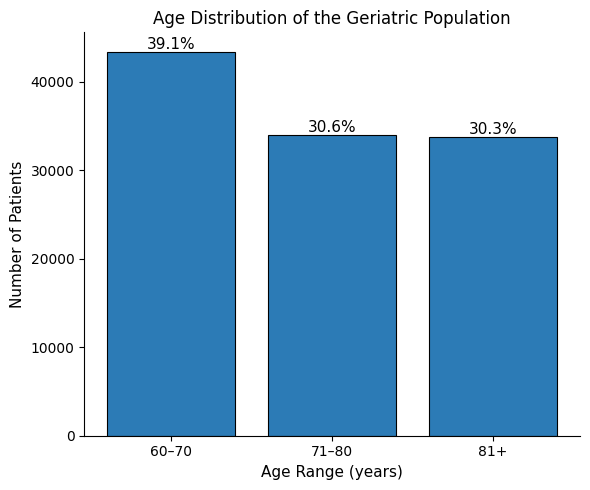

In [ ]:
#Gráfico para ver las diversas edades dentro de la población geriátrica

# Definir rangos de edad
bins = [60, 70, 80, 120]
labels = ["60–70", "71–80", "81+"]

# Crear variable categórica de edad
age_groups = pd.cut(
    base_patient["age_at_admit"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

#Contar pacientes por rango y ordenar
age_counts = age_groups.value_counts().sort_index()
total = age_counts.sum()

#Calcular porcentajes
percentages = (age_counts / total) * 100

#Crear figura con tamaño consistente tipo paper
plt.figure(figsize=(6,5))

#Dibujar barras con estilo sobrio
bars = plt.bar(
    age_counts.index,
    age_counts.values,
    color="#2C7BB6",
    edgecolor="black",
    linewidth=0.8
)

#Quitar bordes superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

#Agregar porcentajes sobre cada barra
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

#Configuración del gráfico
plt.title(
    "Age Distribution of the Geriatric Population",
    fontsize=12
)
plt.xlabel("Age Range (years)", fontsize=11)
plt.ylabel("Number of Patients", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.savefig(
    "age_distribution_geriatric.pdf",
    bbox_inches="tight",
    facecolor="white"   # recomendable para evitar transparencias raras
)
plt.show()

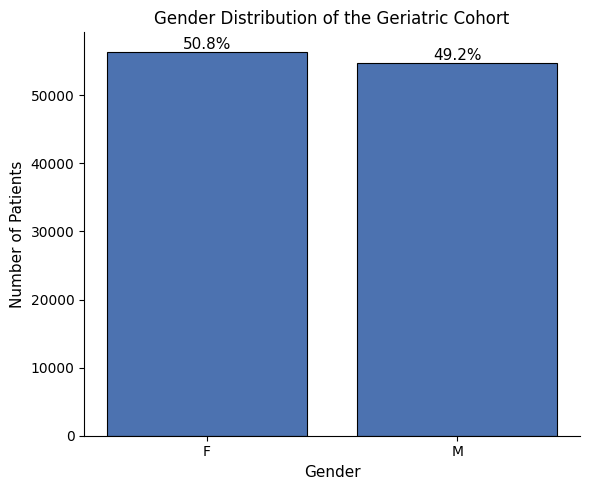

In [ ]:
#Gráfico para ver la distribución por sexo

#Contar pacientes por sexo
sex_counts = base_patient["gender"].value_counts().sort_index()
total = sex_counts.sum()

#Calcular porcentajes
percentages = (sex_counts / total) * 100

#Crear figura tamaño paper consistente
plt.figure(figsize=(6,5))

#Dibujar barras con estilo sobrio
bars = plt.bar(
    sex_counts.index,
    sex_counts.values,
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.8
)

#Quitar bordes superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

#Agregar porcentajes sobre cada barra
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

#Configuración del gráfico
plt.title(
    "Gender Distribution of the Geriatric Cohort",
    fontsize=12
)
plt.xlabel("Gender", fontsize=11)
plt.ylabel("Number of Patients", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.savefig(
    "gender_distribution_geriatric.pdf",
    bbox_inches="tight",
    facecolor="white"
)
plt.show()